<a href="https://colab.research.google.com/github/m22aie202/FM_GenAI/blob/main/m22aie202_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
#Loading dataset CIFAR-10
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

100%|██████████| 170M/170M [00:04<00:00, 42.1MB/s]


In [4]:
#Encoder
class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),   # 16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 8x8
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # 4x4
            nn.ReLU()
        )

        self.flatten_dim = 128 * 4 * 4

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

In [5]:
#Reparameterization
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [6]:
#decoder same as per encoder

class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        self.fc = nn.Linear(latent_dim, 128 * 4 * 4)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),    # 32x32
            nn.Sigmoid()  # important
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 128, 4, 4)
        x = self.deconv(x)
        return x

In [7]:
#now model load
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

In [8]:
#get the model
latent_dim = 128
model = VAE(latent_dim).to(device)


In [9]:
#loss function
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="sum")

    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + beta * kl, recon_loss, kl

In [10]:
#optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [11]:
epochs = 30
beta = 1.0   # standard VAE

In [12]:
train_losses = []
recon_losses = []
kl_losses = []

In [13]:
#training model
for epoch in range(epochs):
    model.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for x, _ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(x)

        loss, r_loss, kl = vae_loss(recon, x, mu, logvar, beta)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += r_loss.item()
        total_kl += kl.item()

    avg_loss = total_loss / len(train_loader.dataset)
    avg_recon = total_recon / len(train_loader.dataset)
    avg_kl = total_kl / len(train_loader.dataset)

    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(f"Epoch [{epoch+1}/{epochs}]  "
          f"Loss: {avg_loss:.4f}  Recon: {avg_recon:.4f}  KL: {avg_kl:.4f}")

Epoch [1/30]  Loss: 1923.7054  Recon: 1898.7685  KL: 24.9368
Epoch [2/30]  Loss: 1846.4187  Recon: 1814.2058  KL: 32.2129
Epoch [3/30]  Loss: 1835.0545  Recon: 1800.0791  KL: 34.9754
Epoch [4/30]  Loss: 1830.5715  Recon: 1793.6974  KL: 36.8741
Epoch [5/30]  Loss: 1827.3232  Recon: 1788.8953  KL: 38.4279
Epoch [6/30]  Loss: 1824.8196  Recon: 1785.0325  KL: 39.7871
Epoch [7/30]  Loss: 1823.1851  Recon: 1782.5528  KL: 40.6323
Epoch [8/30]  Loss: 1822.3424  Recon: 1781.1927  KL: 41.1497
Epoch [9/30]  Loss: 1821.3738  Recon: 1779.7411  KL: 41.6327
Epoch [10/30]  Loss: 1820.7354  Recon: 1778.7176  KL: 42.0178
Epoch [11/30]  Loss: 1820.1310  Recon: 1777.7439  KL: 42.3871
Epoch [12/30]  Loss: 1819.7176  Recon: 1776.9518  KL: 42.7658
Epoch [13/30]  Loss: 1819.3577  Recon: 1776.3580  KL: 42.9997
Epoch [14/30]  Loss: 1818.8675  Recon: 1775.6775  KL: 43.1900
Epoch [15/30]  Loss: 1818.8114  Recon: 1775.4571  KL: 43.3543
Epoch [16/30]  Loss: 1818.4724  Recon: 1774.9537  KL: 43.5187
Epoch [17/30]  Lo

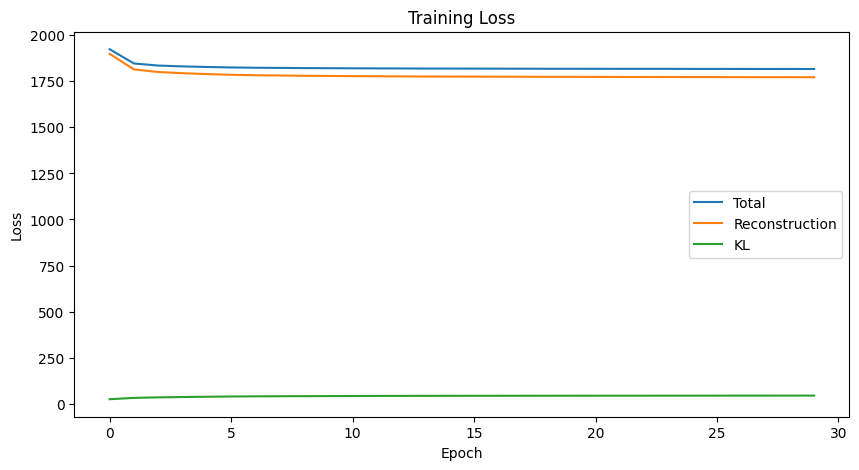

In [14]:
#plotting
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Total")
plt.plot(recon_losses, label="Reconstruction")
plt.plot(kl_losses, label="KL")
plt.legend()
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [15]:
torch.save(model.state_dict(), "m22aie202_vae_cifar.pth")

In [16]:
model.eval()

with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    samples = model.decoder(z).cpu()

In [17]:
grid = make_grid(samples, nrow=4)

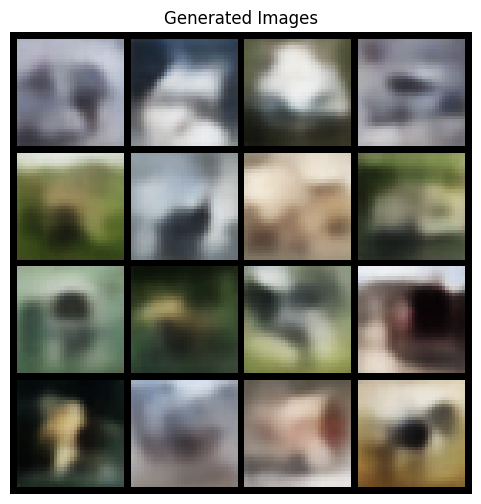

In [18]:
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid, (1,2,0)))
plt.axis("off")
plt.title("Generated Images")
plt.show()